System : Lorenz attractor  ẋ=σ(y-x), ẏ=x(ρ-z)-y, ż=xy-βz
Dim    : 3   Vars: ['x', 'y', 'z']

Data shape : (2000, 3)   t ∈ [0.00, 19.99]


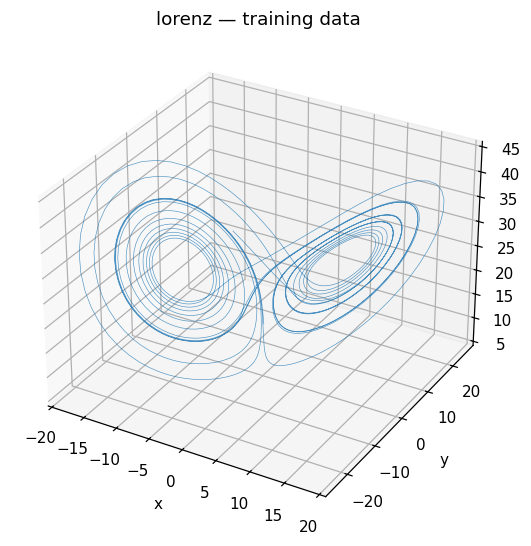


Fit time : 0.523 s  (grid: uniform)

Discovered equations:
  x' = (+10.0000)·y + (-10.0000)·x
  y' = (-1.0000)·y + (+28.0000)·x + (-1.0000)·xz
  z' = (-2.6667)·z + (+1.0000)·xy
Total windows: 282  |  width: 0.300s  |  overlap: 50%  |  step: 0.150s


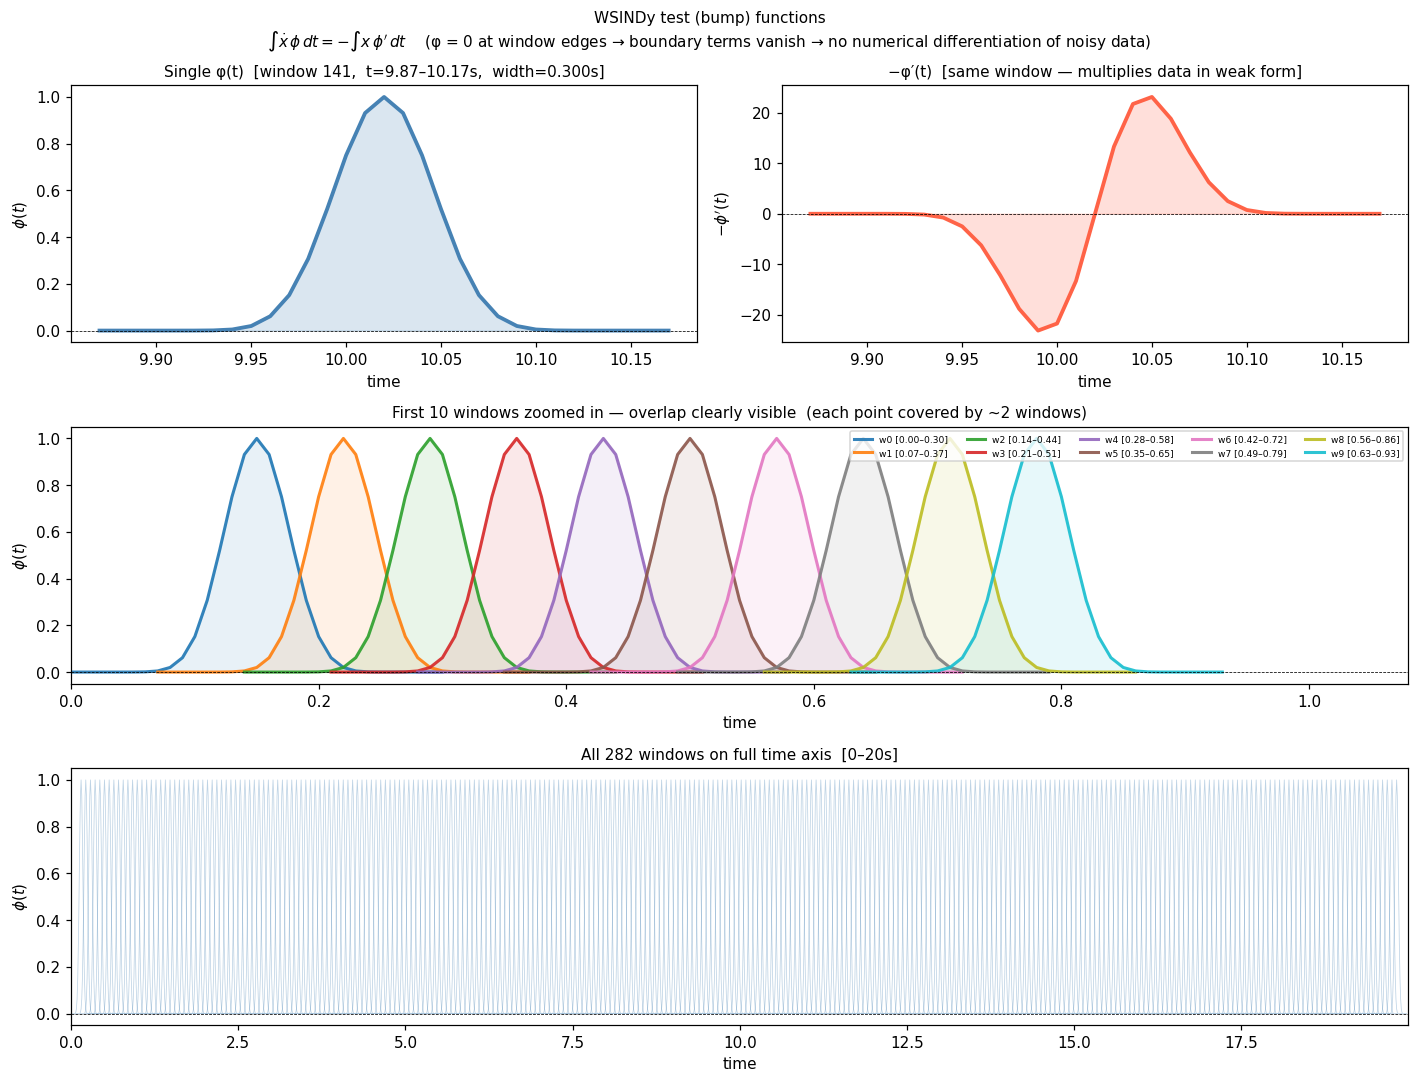

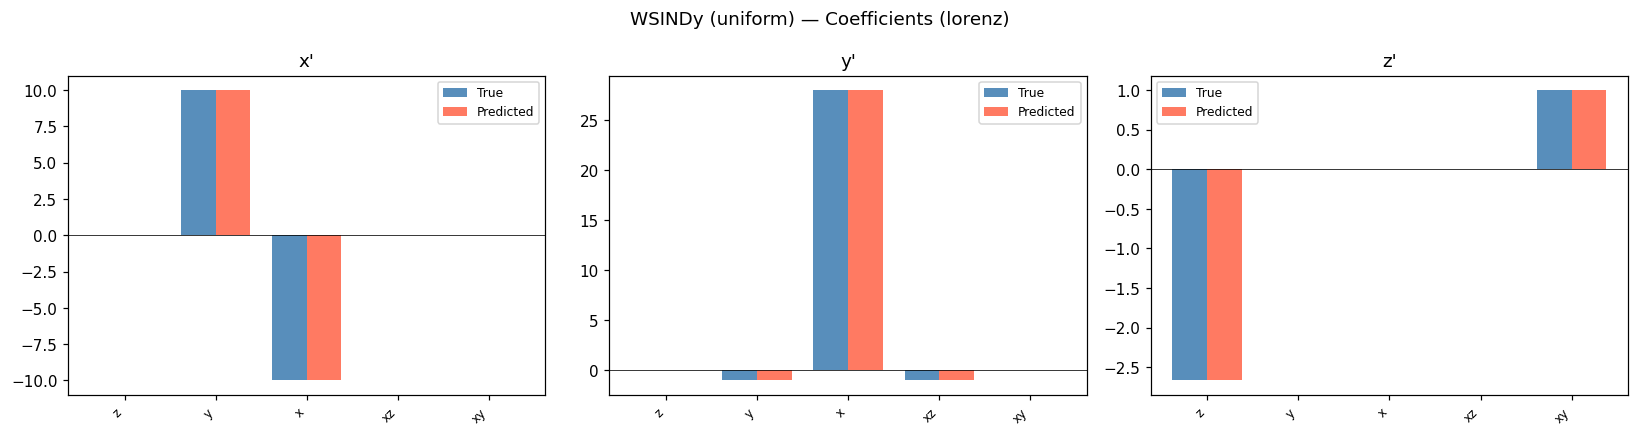

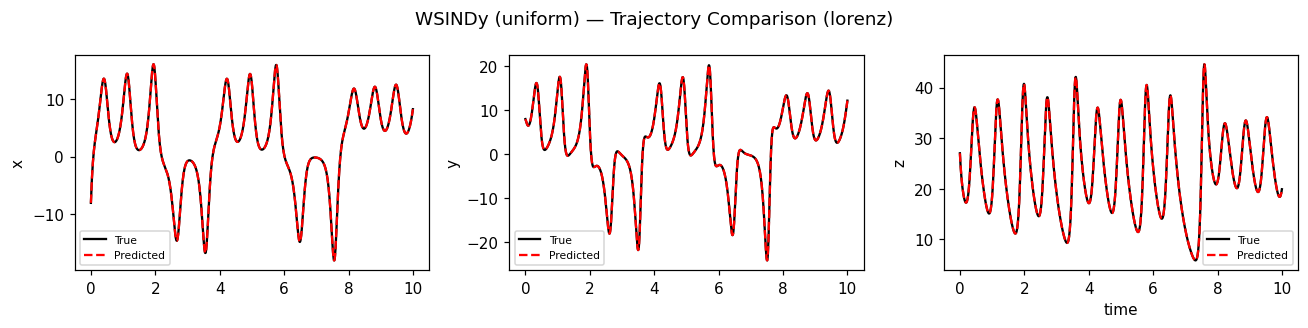


  WSINDy (uniform)
  Traj. L2 error [x]  : 0.0002
  Traj. L2 error [y]  : 0.0003
  Traj. L2 error [z]  : 0.0001
  Total traj. L2 error    : 0.0001
  Coefficient L2 error    : 0.0000
  Precision               : 1.000
  Recall                  : 1.000
  Fit time : 0.523 s

Results saved → results/wsindy_lorenz_results.pkl
  noise=0.00  traj_err=0.0001  coef_err=3.118754719828867e-11
  noise=0.01  traj_err=0.4480  coef_err=0.009518349195230282
  noise=0.05  traj_err=0.5364  coef_err=0.045750820266130275
  noise=0.10  traj_err=0.5942  coef_err=0.014024176602865621
  noise=0.20  traj_err=0.7243  coef_err=0.21264298503696036


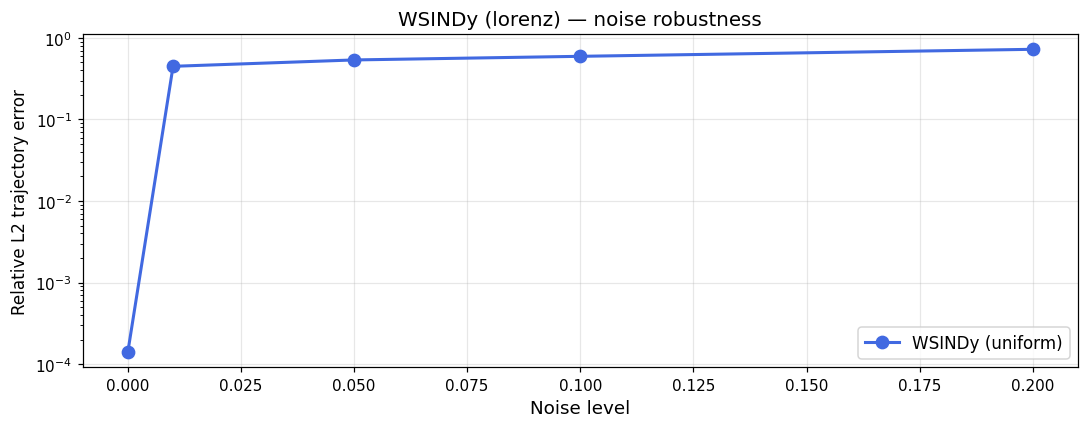

In [ ]:
# =============================================================================
# 02_WSINDy.py
# Weak-form SINDy on any registered ODESystem.
# Port of MathBioCU/PyWSINDy_ODE (Messenger & Bortz 2021).
# =============================================================================

# %% ── USER PARAMETERS ────────────────────────────────────────────────────────

import sys, os
sys.path.insert(0, os.getcwd())
from ode_systems import SYSTEMS, list_systems

# System selection
SYSTEM_KEY = "lorenz"
SYSTEM     = SYSTEMS[SYSTEM_KEY]

# Initial condition (must have SYSTEM.n_dim entries)
X0 = [-8.0, 8.0, 27.0]

# Integration
T_SPAN      = (0.0, 20.0)
DT          = 0.01
NOISE_LEVEL = 0.00
SEED        = 42

# Candidate library
# WSINDy uses monomials up to degree POLY_DEGREE plus optional trig terms.
POLY_DEGREE = 3
TRIGS       = []    # e.g. [1] adds sin(x_i) and cos(x_i) for each variable

# Optimiser
LD           = 0.05    # sequential-thresholding sparsity threshold
GAMMA        = 1e-8    # Tikhonov regularisation (0 or float('-inf') for none)
USE_GLS      = 1e-12   # generalised-least-squares weight (0 to disable)
SCALED_THETA = 0       # column normalisation: 0=off, 2=L2-norm

# Test-function grid
# 'uniform'  — evenly spaced windows, simpler and usually sufficient
# 'adaptive' — windows concentrated where the signal varies most
GRID_TYPE = "uniform"

# Uniform grid
L_UNIFORM = 30     # window width in number of timesteps
OVERLAP   = 0.5    # fractional overlap between adjacent windows

# Adaptive grid (only used when GRID_TYPE='adaptive')
R_WHM      = 30    # test-function half-max radius (timesteps)
K_ADAPTIVE = 120   # number of test-function centres
P_ADAPTIVE = 2     # polynomial degree of test functions
TAU_P      = 16    # tail decay: function ≈ 10^{-tau_p} at boundary

# Evaluation
T_EVAL_END         = 10.0
SWEEP_NOISE_LEVELS = [0.0, 0.01, 0.05, 0.1, 0.2]

RESULTS_FILE = f"results/wsindy_{SYSTEM_KEY}_results.pkl"

# %% ── IMPORTS ─────────────────────────────────────────────────────────────────

import pickle, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams["figure.dpi"] = 110

from wsindy_core import WSINDy
from ode_utils import (
    generate_data,
    plot_phase_portrait, plot_trajectories, plot_coefficient_comparison,
    plot_noise_sweep, relative_l2_error, coefficient_error, precision_recall,
    print_metrics, metrics_dict, build_true_coef_matrix,
    print_discovered_equations,
)

os.makedirs("results", exist_ok=True)
print(f"System : {SYSTEM.description}")
print(f"Dim    : {SYSTEM.n_dim}   Vars: {SYSTEM.var_names}")

# %% ── 1. GENERATE DATA ────────────────────────────────────────────────────────

t, X = generate_data(SYSTEM, X0, T_SPAN, DT,
                     noise_level=NOISE_LEVEL, seed=SEED)
print(f"\nData shape : {X.shape}   t ∈ [{t[0]:.2f}, {t[-1]:.2f}]")

fig = plot_phase_portrait(t, X, SYSTEM.var_names,
                           title=f"{SYSTEM_KEY} — training data")
plt.tight_layout()
plt.savefig(f"results/wsindy_{SYSTEM_KEY}_phase.png", dpi=150, facecolor="none", transparent= True)
plt.show()

# %% ── 2. FIT WSINDy ───────────────────────────────────────────────────────────

polys = np.arange(0, POLY_DEGREE + 1)

model = WSINDy(
    polys=polys,
    trigs=TRIGS,
    scaled_theta=SCALED_THETA,
    ld=LD,
    gamma=GAMMA,
    use_gls=USE_GLS,
)

t0 = time.time()
if GRID_TYPE == "adaptive":
    model.fit_adaptive(X, t, r_whm=R_WHM, K=K_ADAPTIVE,
                       p=P_ADAPTIVE, tau_p=TAU_P,
                       custom_library=SYSTEM.custom_library)
else:
    model.fit_uniform(X, t, L=L_UNIFORM, overlap=OVERLAP,
                      custom_library=SYSTEM.custom_library)
fit_time = time.time() - t0

print(f"\nFit time : {fit_time:.3f} s  (grid: {GRID_TYPE})")

feature_names = model.get_feature_names()
coef          = model.get_coefficients()   # (n_eqs, n_features)

print_discovered_equations(coef, feature_names, SYSTEM.var_names)

# %% ── 2b. VISUALISE TEST (BUMP) FUNCTIONS ───────────────────────────────────
# Shows a sample of the test functions φ(t) and their derivatives -φ'(t).
# The weak form integrates data against φ (left side) and uses -φ' to
# move the time derivative onto the smooth test function (right side),
# avoiding any numerical differentiation of the noisy data.

def plot_bump_functions(t, model, grid_type, L=30, overlap=0.5, n_show=6,
                        figsize=(13, 10)):
    """Three-panel plot: single bump zoomed, its derivative, zoomed overlap view,
    and full-axis coverage."""
    p = 16
    g, gp = model._basis_fcn(p, p)
    M = len(t)

    # rebuild grid
    ovlp = int(np.floor(L * (1 - np.sqrt(1 - overlap**(1/p)))))
    grid, a, b = [], 0, int(L)
    grid.append([a, b])
    while b - ovlp + L <= M - 1:
        a = b - ovlp; b = a + int(L)
        grid.append([a, b])
    grid = np.array(grid)
    n_windows  = len(grid)
    window_sec = t[int(L)] - t[0]

    print(f"Total windows: {n_windows}  |  width: {window_sec:.3f}s  "
          f"|  overlap: {int(overlap*100)}%  |  step: {window_sec*(1-overlap):.3f}s")

    fig = plt.figure(figsize=figsize)
    ax_phi  = fig.add_subplot(3, 2, 1)
    ax_dphi = fig.add_subplot(3, 2, 2)
    ax_zoom = fig.add_subplot(3, 1, 2)
    ax_full = fig.add_subplot(3, 1, 3)

    # ── top: single window in detail ─────────────────────────────────────────
    ki_mid = n_windows // 2
    t1z, tkz = int(grid[ki_mid][0]), int(grid[ki_mid][1])
    tg_z = t[t1z:tkz+1]
    ax_phi.plot(tg_z, g(tg_z, t[t1z], t[tkz]), color="steelblue", lw=2.5)
    ax_phi.fill_between(tg_z, g(tg_z, t[t1z], t[tkz]), alpha=0.2, color="steelblue")
    ax_phi.set_title(f"Single φ(t)  [window {ki_mid},  "
                      f"t={t[t1z]:.2f}–{t[tkz]:.2f}s,  width={window_sec:.3f}s]",
                      fontsize=10)
    ax_phi.set_xlabel("time"); ax_phi.set_ylabel(r"$\phi(t)$")
    ax_phi.axhline(0, color="k", lw=0.5, ls="--")

    ax_dphi.plot(tg_z, -gp(tg_z, t[t1z], t[tkz]), color="tomato", lw=2.5)
    ax_dphi.fill_between(tg_z, -gp(tg_z, t[t1z], t[tkz]), alpha=0.2, color="tomato")
    ax_dphi.set_title("−φ′(t)  [same window — multiplies data in weak form]",
                       fontsize=10)
    ax_dphi.set_xlabel("time"); ax_dphi.set_ylabel(r"$-\phi'(t)$")
    ax_dphi.axhline(0, color="k", lw=0.5, ls="--")

    # ── middle: first 10 windows zoomed — overlap is visible ─────────────────
    n_zoom = min(10, n_windows)
    zoom_colors = plt.cm.tab10(np.linspace(0, 1, n_zoom))
    t_zoom_end = t[int(grid[n_zoom-1][1])] + window_sec * 0.5
    for ki in range(n_zoom):
        t1, tk = int(grid[ki][0]), int(grid[ki][1])
        tg = t[t1:tk+1]
        phi = g(tg, t[t1], t[tk])
        ax_zoom.plot(tg, phi, color=zoom_colors[ki], lw=2.0, alpha=0.9,
                      label=f"w{ki} [{t[t1]:.2f}–{t[tk]:.2f}]")
        ax_zoom.fill_between(tg, phi, alpha=0.1, color=zoom_colors[ki])
    ax_zoom.set_xlim(t[0], t_zoom_end)
    ax_zoom.set_title(f"First {n_zoom} windows zoomed in — overlap clearly visible  "
                       f"(each point covered by ~{round(1/(1-overlap))} windows)",
                       fontsize=10)
    ax_zoom.set_xlabel("time"); ax_zoom.set_ylabel(r"$\phi(t)$")
    ax_zoom.axhline(0, color="k", lw=0.5, ls="--")
    ax_zoom.legend(fontsize=6, ncol=5, loc="upper right")

    # ── bottom: all windows on full axis ──────────────────────────────────────
    for ki in range(n_windows):
        t1, tk = int(grid[ki][0]), int(grid[ki][1])
        tg = t[t1:tk+1]
        ax_full.plot(tg, g(tg, t[t1], t[tk]), color="steelblue", lw=0.5, alpha=0.35)
    ax_full.set_title(f"All {n_windows} windows on full time axis  "
                       f"[0–{t[-1]:.0f}s]", fontsize=10)
    ax_full.set_xlabel("time"); ax_full.set_ylabel(r"$\phi(t)$")
    ax_full.axhline(0, color="k", lw=0.5, ls="--")
    ax_full.set_xlim(t[0], t[-1])

    fig.suptitle(
        "WSINDy test (bump) functions\n"
        r"$\int \dot{x}\,\phi\,dt = -\int x\,\phi'\,dt$  "
        r"  (φ = 0 at window edges → boundary terms vanish → "
        r"no numerical differentiation of noisy data)",
        fontsize=10
    )
    plt.tight_layout()
    return fig


fig_bump = plot_bump_functions(t, model, GRID_TYPE,
                               L=L_UNIFORM, overlap=OVERLAP, n_show=6)
plt.savefig(f"results/wsindy_{SYSTEM_KEY}_bump_functions.png", dpi=150, facecolor="none", transparent= True)
plt.show()

# %% ── 3. COEFFICIENT COMPARISON ──────────────────────────────────────────────

true_coef = build_true_coef_matrix(SYSTEM, feature_names)

if true_coef is not None:
    active = np.where(
        np.any(np.abs(true_coef) > 1e-4, axis=0) |
        np.any(np.abs(coef)      > 1e-4, axis=0)
    )[0]
    dot_names = [f"{v}'" for v in SYSTEM.var_names]
    fig = plot_coefficient_comparison(
        true_coef[:, active], coef[:, active],
        [feature_names[i] for i in active],
        eq_names=dot_names,
        title=f"WSINDy ({GRID_TYPE}) — Coefficients ({SYSTEM_KEY})",
    )
    plt.tight_layout()
    plt.savefig(f"results/wsindy_{SYSTEM_KEY}_coefficients.png", dpi=150, facecolor="none", transparent= True)
    plt.show()
else:
    print("No ground-truth coefficients registered for this system.")

# %% ── 4. SIMULATE & COMPARE ──────────────────────────────────────────────────

t_test      = t[t <= T_EVAL_END]
X_true_test = X[:len(t_test)]

try:
    X_pred = model.simulate(X0, (t_test[0], t_test[-1]), t_test)
    sim_ok = True
except Exception as e:
    print(f"Simulation failed: {e}")
    X_pred = np.full_like(X_true_test, np.nan)
    sim_ok = False

if sim_ok:
    fig = plot_trajectories(
        t_test, X_true_test, X_pred, SYSTEM.var_names,
        title=f"WSINDy ({GRID_TYPE}) — Trajectory Comparison ({SYSTEM_KEY})",
    )
    plt.savefig(f"results/wsindy_{SYSTEM_KEY}_trajectory.png", dpi=150, facecolor="none", transparent= True)
    plt.show()

# %% ── 5. METRICS & SAVE ───────────────────────────────────────────────────────

per_dim, total = relative_l2_error(X_true_test, X_pred)
coef_err  = (coefficient_error(true_coef.flatten(), coef.flatten())
             if true_coef is not None else None)
prec, rec = (precision_recall(true_coef.flatten(), coef.flatten())
             if true_coef is not None else (None, None))

print_metrics(f"WSINDy ({GRID_TYPE})", per_dim, total, coef_err, prec, rec,
              var_names=SYSTEM.var_names)
print(f"  Fit time : {fit_time:.3f} s")

results = dict(
    system_key=SYSTEM_KEY,
    coef=coef,
    true_coef=true_coef,
    feature_names=feature_names,
    var_names=SYSTEM.var_names,
    **metrics_dict(f"WSINDy ({GRID_TYPE})", per_dim, total,
                   coef_err, prec, rec, fit_time),
    t_test=t_test,
    X_true=X_true_test,
    X_pred=X_pred,
    params=dict(ld=LD, gamma=GAMMA, poly_degree=POLY_DEGREE,
                grid_type=GRID_TYPE, noise_level=NOISE_LEVEL),
)
with open(RESULTS_FILE, "wb") as fh:
    pickle.dump(results, fh)
print(f"\nResults saved → {RESULTS_FILE}")

# %% ── 6. NOISE SWEEP ─────────────────────────────────────────────────────────

traj_errs, coef_errs = [], []

for nl in SWEEP_NOISE_LEVELS:
    _, Xn = generate_data(SYSTEM, X0, T_SPAN, DT, noise_level=nl, seed=SEED)
    mw = WSINDy(polys=polys, trigs=TRIGS, scaled_theta=SCALED_THETA,
                ld=LD, gamma=GAMMA, use_gls=USE_GLS)
    if GRID_TYPE == "adaptive":
        mw.fit_adaptive(Xn, t, r_whm=R_WHM, K=K_ADAPTIVE,
                        p=P_ADAPTIVE, tau_p=TAU_P,
                        custom_library=SYSTEM.custom_library)
    else:
        mw.fit_uniform(Xn, t, L=L_UNIFORM, overlap=OVERLAP,
                       custom_library=SYSTEM.custom_library)
    try:
        Xp = mw.simulate(X0, (t_test[0], t_test[-1]), t_test)
        _, te = relative_l2_error(X_true_test, Xp)
    except Exception:
        te = np.nan
    ce = (coefficient_error(true_coef.flatten(), mw.get_coefficients().flatten())
          if true_coef is not None else np.nan)
    traj_errs.append(te)
    coef_errs.append(ce)
    print(f"  noise={nl:.2f}  traj_err={te:.4f}  coef_err={ce}")

fig = plot_noise_sweep(SWEEP_NOISE_LEVELS,
                       {f"WSINDy ({GRID_TYPE})": traj_errs},
                       metric="traj",
                       title=f"WSINDy ({SYSTEM_KEY}) — noise robustness")
plt.savefig(f"results/wsindy_{SYSTEM_KEY}_noise_sweep.png", dpi=150, facecolor="none", transparent= True)
plt.show()